# Chapter 02: Summary Statistics

Source span: printed pages 13-24; PDF pages 32-42 of `Directional Statistics.pdf`. The PDF span was used only to orient the chapter sequence and terminology; the prose, examples, code, and figures below are original course material. In the extracted source map, PDF page 42 closes Chapter 02 and PDF page 43 begins Chapter 03, so the assigned printed page 24 appears to be the transition/blank page in this copy.

## Chapter Question

How can a sample of directions be summarized without letting an arbitrary cut in the circle decide the answer?

This chapter answers that question by replacing arithmetic on angle labels with geometry on the unit circle. Each observation becomes a unit vector. The mean direction is the direction of the vector resultant, the mean resultant length is the concentration signal, dispersion is measured by distances that wrap, medians are balance directions on semicircles, and trigonometric moments summarize repeated angular structure. The final section asks what survives when observations arrive grouped into bins rather than as exact angles.


## Computational Translation Guide

| Source idea | Computational object | What must be checked |
| --- | --- | --- |
| Direction on the circle | `theta mod 2*pi`, unit vector `(cos(theta), sin(theta))`, or complex number `exp(1j*theta)` | Changing the zero direction should rotate labels, not change geometry. |
| Mean direction | `atan2(mean(sin theta), mean(cos theta))` when the resultant length is nonzero | `sum(sin(theta - mean_direction))` is zero up to floating error. |
| Mean resultant length | `Rbar = abs(mean(exp(1j*theta)))` | `0 <= Rbar <= 1`; high values mean concentrated directions. |
| Circular variance and chord dispersion | `V = 1 - Rbar`; `D(alpha) = mean(1 - cos(theta - alpha))` | `D(mean_direction) = V` and `D(alpha) = V + Rbar*(1 - cos(alpha - mean_direction))`. |
| Circular median and mean deviation | Minimize mean shortest-arc distance from `alpha` to the sample | The minimizer can differ from the vector mean when a few directions oppose the main cluster. |
| Trigonometric moments | `m_p = mean(exp(1j*p*theta))` and centered versions `mean(exp(1j*p*(theta - mean)))` | Moment phases and lengths detect skew, kurtosis, and p-fold structure. |
| Grouped observations | Replace each bin by its midpoint, then correct resultant lengths by `a(h) = (h/2)/sin(h/2)` | The correction is small for fine bins and cannot repair a bad cut point. |

The notebook uses Matplotlib for durable unit-circle diagrams, Plotly for the cutpoint/bin-width exploration, pandas for auditable tables, SciPy for the nonsmooth median minimization, and SymPy for the grouping-correction series.


## Route Through The Chapter

1. Build the resultant vector from unit vectors and watch a linear mean fail when the cut point moves.
2. Use chord dispersion and shortest-arc dispersion to separate the mean direction from a circular median.
3. Compute trigonometric moments and turn skewness/kurtosis into quantities that can be inspected.
4. Run an applied lab where a cut point and a grouping width are deliberately varied.
5. Finish with sanity checks for identities, invariance, artifact existence, and nonzero artifact sizes.

Artifact plan:

- `artifacts/chapter-02/figures/resultant-cutpoint-failure.png`
- `artifacts/chapter-02/figures/dispersion-median-losses.png`
- `artifacts/chapter-02/figures/trigonometric-moments-dashboard.png`
- `artifacts/chapter-02/interactive/cutpoint-grouping-lab.html`
- `artifacts/chapter-02/tables/trigonometric-moments.csv`
- `artifacts/chapter-02/tables/grouping-correction.csv`
- `artifacts/chapter-02/checks/numeric-checks.json`
- `artifacts/chapter-02/checks/final-sanity.json`


In [1]:
from pathlib import Path
import sys


def find_book_root(start: Path) -> Path:
    start = start.resolve()
    candidates = []
    for candidate in [start, *start.parents]:
        candidates.append(candidate)
        candidates.append(candidate / "Directional-Statistics")
    seen = set()
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (
            (candidate / "AGENTS.md").exists()
            and (candidate / "scripts" / "validate_dirstats_course.py").exists()
            and (candidate / "utils").exists()
        ):
            return candidate
    raise RuntimeError("Could not locate Directional-Statistics course root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-02"
SOURCE_SPAN = {
    "printed_pages": "13-24",
    "pdf_pages": "32-42",
    "source_use": "orientation only; no copied prose, tables, screenshots, page crops, or solutions",
}
print(f"Course root: {BOOK_ROOT}")
print(f"Artifact topic: {TOPIC}")
SOURCE_SPAN


Course root: D:\Geometry\Directional-Statistics
Artifact topic: chapter-02


{'printed_pages': '13-24',
 'pdf_pages': '32-42',
 'source_use': 'orientation only; no copied prose, tables, screenshots, page crops, or solutions'}

In [2]:
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
import sympy as sp
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.validation import assert_artifacts

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#30343b",
    "axes.labelcolor": "#1f2933",
    "xtick.color": "#1f2933",
    "ytick.color": "#1f2933",
    "font.size": 10,
})

TAU = 2 * np.pi
DEG = np.pi / 180
RNG = np.random.default_rng(202602)


def wrap_2pi(theta):
    return np.mod(theta, TAU)


def wrap_pi(theta):
    return (np.asarray(theta) + np.pi) % TAU - np.pi


def angular_abs_distance(theta, alpha):
    return np.abs(wrap_pi(np.asarray(theta) - alpha))


def resultant(theta):
    theta = np.asarray(theta, dtype=float)
    zbar = np.exp(1j * theta).mean()
    rbar = abs(zbar)
    mu = float(np.mod(np.angle(zbar), TAU)) if rbar > 1e-14 else np.nan
    return {
        "C": float(zbar.real),
        "S": float(zbar.imag),
        "Rbar": float(rbar),
        "mean_direction": mu,
        "resultant_length": float(len(theta) * rbar),
        "zbar": zbar,
    }


def chord_dispersion(theta, alpha):
    return float(np.mean(1 - np.cos(np.asarray(theta) - alpha)))


def circular_l1_loss(theta, alpha):
    return float(np.mean(angular_abs_distance(theta, alpha)))


def circular_median(theta):
    theta = wrap_2pi(np.asarray(theta, dtype=float))
    grid = np.linspace(0, TAU, 1440, endpoint=False)
    losses = np.array([circular_l1_loss(theta, alpha) for alpha in grid])
    best = float(grid[int(np.argmin(losses))])
    width = TAU / 360
    refined = optimize.minimize_scalar(
        lambda alpha: circular_l1_loss(theta, alpha),
        bounds=(best - width, best + width),
        method="bounded",
        options={"xatol": 1e-13},
    )
    return float(wrap_2pi(refined.x)), float(refined.fun)


def linear_mean_after_cut(theta, cut):
    shifted = wrap_2pi(np.asarray(theta) - cut) + cut
    return float(wrap_2pi(np.mean(shifted)))


def trig_moment(theta, p, center=0.0):
    return np.exp(1j * p * (np.asarray(theta) - center)).mean()


def grouped_midpoints(theta, h):
    theta = wrap_2pi(np.asarray(theta))
    bin_count = int(round(TAU / h))
    if not np.isclose(bin_count * h, TAU):
        raise ValueError("h must divide 2*pi for this equal-bin demonstration")
    indices = np.floor(theta / h).astype(int) % bin_count
    return (indices + 0.5) * h, indices, bin_count


def grouping_correction_factor(h):
    return float((h / 2) / np.sin(h / 2))


def circular_range(theta):
    ordered = np.sort(wrap_2pi(theta))
    gaps = np.diff(np.r_[ordered, ordered[0] + TAU])
    return float(TAU - gaps.max()), float(gaps.max())


def deg(theta):
    return np.rad2deg(wrap_2pi(theta))


def shortest_deg(theta):
    return np.rad2deg(wrap_pi(theta))


def unit_circle(ax, *, color="#c8d0d9"):
    t = np.linspace(0, TAU, 500)
    ax.plot(np.cos(t), np.sin(t), color=color, lw=1.2)
    ax.axhline(0, color="#c8d0d9", lw=0.8)
    ax.axvline(0, color="#c8d0d9", lw=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.18, 1.18)
    ax.set_ylim(-1.18, 1.18)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])


## Unit-vector Resultant And Mean Direction

Angle labels are not measurements on a line. The safe representation is the unit vector `x_j = (cos(theta_j), sin(theta_j))`. The sample resultant is the average of these vectors, and its polar coordinates give the circular mean direction and mean resultant length.

The synthetic sample below deliberately straddles the zero direction. A linear mean computed after cutting at zero lands far away from the cluster. The resultant points into the cluster because it never unwraps the circle into a line.


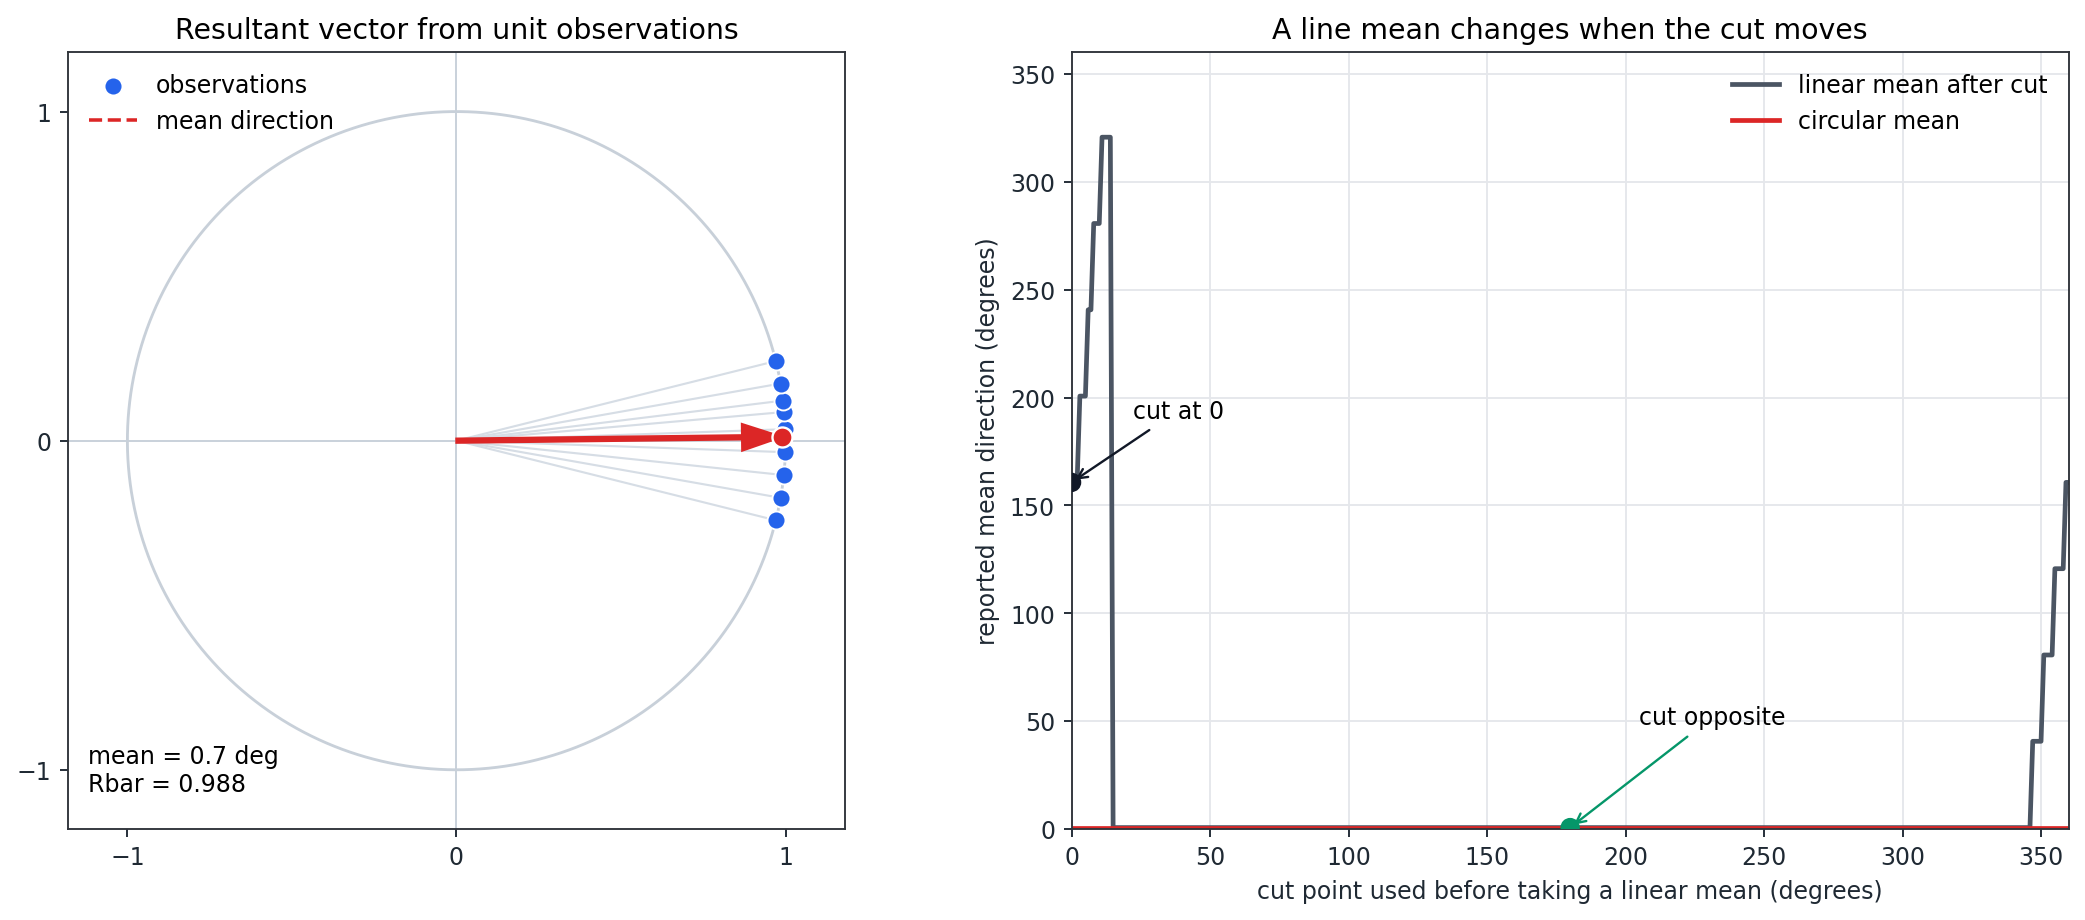

{'n': 9,
 'mean_direction_degrees': 0.6732760516106343,
 'mean_resultant_length': 0.9880961476245924,
 'linear_mean_cut_at_zero_degrees': 160.66666666666669,
 'linear_mean_cut_at_180_degrees': 0.6666666666666591,
 'cutpoint_swing_degrees': 160.00000000000003}

In [3]:
cutpoint_degrees = np.array([346, 350, 354, 358, 2, 5, 7, 10, 14], dtype=float)
cutpoint_theta = np.deg2rad(cutpoint_degrees)
cutpoint_summary = resultant(cutpoint_theta)
mu = cutpoint_summary["mean_direction"]
rbar = cutpoint_summary["Rbar"]
linear_zero = linear_mean_after_cut(cutpoint_theta, 0.0)
linear_opposite = linear_mean_after_cut(cutpoint_theta, np.pi)

cut_grid = np.linspace(0, TAU, 361)
linear_curve = np.array([linear_mean_after_cut(cutpoint_theta, cut) for cut in cut_grid])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.3), constrained_layout=True)
ax = axes[0]
unit_circle(ax)
x = np.cos(cutpoint_theta)
y = np.sin(cutpoint_theta)
for xi, yi in zip(x, y):
    ax.plot([0, xi], [0, yi], color="#d6dde5", lw=0.9, zorder=1)
ax.scatter(x, y, s=58, color="#2563eb", edgecolor="white", linewidth=0.8, zorder=3, label="observations")
ax.arrow(0, 0, cutpoint_summary["C"], cutpoint_summary["S"],
         width=0.012, head_width=0.08, length_includes_head=True,
         color="#dc2626", zorder=4)
ax.plot([0, np.cos(mu)], [0, np.sin(mu)], color="#dc2626", lw=1.5, ls="--", label="mean direction")
ax.scatter([cutpoint_summary["C"]], [cutpoint_summary["S"]], s=72, color="#dc2626", edgecolor="white", zorder=5)
ax.set_title("Resultant vector from unit observations")
ax.text(-1.12, -1.08, f"mean = {deg(mu):.1f} deg\nRbar = {rbar:.3f}", ha="left", va="bottom")
ax.legend(loc="upper left", frameon=False)

ax = axes[1]
ax.plot(np.rad2deg(cut_grid), np.rad2deg(linear_curve), color="#4b5563", lw=2.0, label="linear mean after cut")
ax.axhline(deg(mu), color="#dc2626", lw=2.0, label="circular mean")
ax.scatter([0, 180], [deg(linear_zero), deg(linear_opposite)], color=["#111827", "#059669"], s=52, zorder=5)
ax.annotate("cut at 0", xy=(0, deg(linear_zero)), xytext=(22, deg(linear_zero) + 30),
            arrowprops={"arrowstyle": "->", "color": "#111827"})
ax.annotate("cut opposite", xy=(180, deg(linear_opposite)), xytext=(205, deg(linear_opposite) + 48),
            arrowprops={"arrowstyle": "->", "color": "#059669"})
ax.set_xlim(0, 360)
ax.set_ylim(0, 360)
ax.set_xlabel("cut point used before taking a linear mean (degrees)")
ax.set_ylabel("reported mean direction (degrees)")
ax.set_title("A line mean changes when the cut moves")
ax.grid(True, color="#e5e7eb", lw=0.8)
ax.legend(loc="upper right", frameon=False)

resultant_path = save_matplotlib(fig, TOPIC, "figures", "resultant-cutpoint-failure.png", dpi=170)
plt.close(fig)
display_artifact(resultant_path, width=900)

resultant_diagnostics = {
    "n": int(len(cutpoint_theta)),
    "mean_direction_degrees": float(deg(mu)),
    "mean_resultant_length": float(rbar),
    "linear_mean_cut_at_zero_degrees": float(deg(linear_zero)),
    "linear_mean_cut_at_180_degrees": float(deg(linear_opposite)),
    "cutpoint_swing_degrees": float(abs(shortest_deg(linear_zero - linear_opposite))),
}
resultant_diagnostics


The left panel is the embedding approach: observations are points on the unit circle, and the red center-of-mass vector is the statistic. The right panel is the failure mode: a linear mean needs a cut point, and moving that cut point changes the reported answer. The circular mean is stable because adding a constant to every angle just rotates the resultant.


## Concentration, Dispersion, And A Circular Median

The mean resultant length `Rbar` is a concentration statistic. It is near one when the unit vectors point together and near zero when the resultant cancels. The circular variance `V = 1 - Rbar` is useful because it is exactly the minimum of the chord-dispersion function

`D(alpha) = mean(1 - cos(theta_j - alpha))`.

A median direction is different. It minimizes average shortest-arc distance. That criterion uses arc length rather than chord loss, so a point near the opposite side of the circle can pull the vector mean more than it pulls the median.


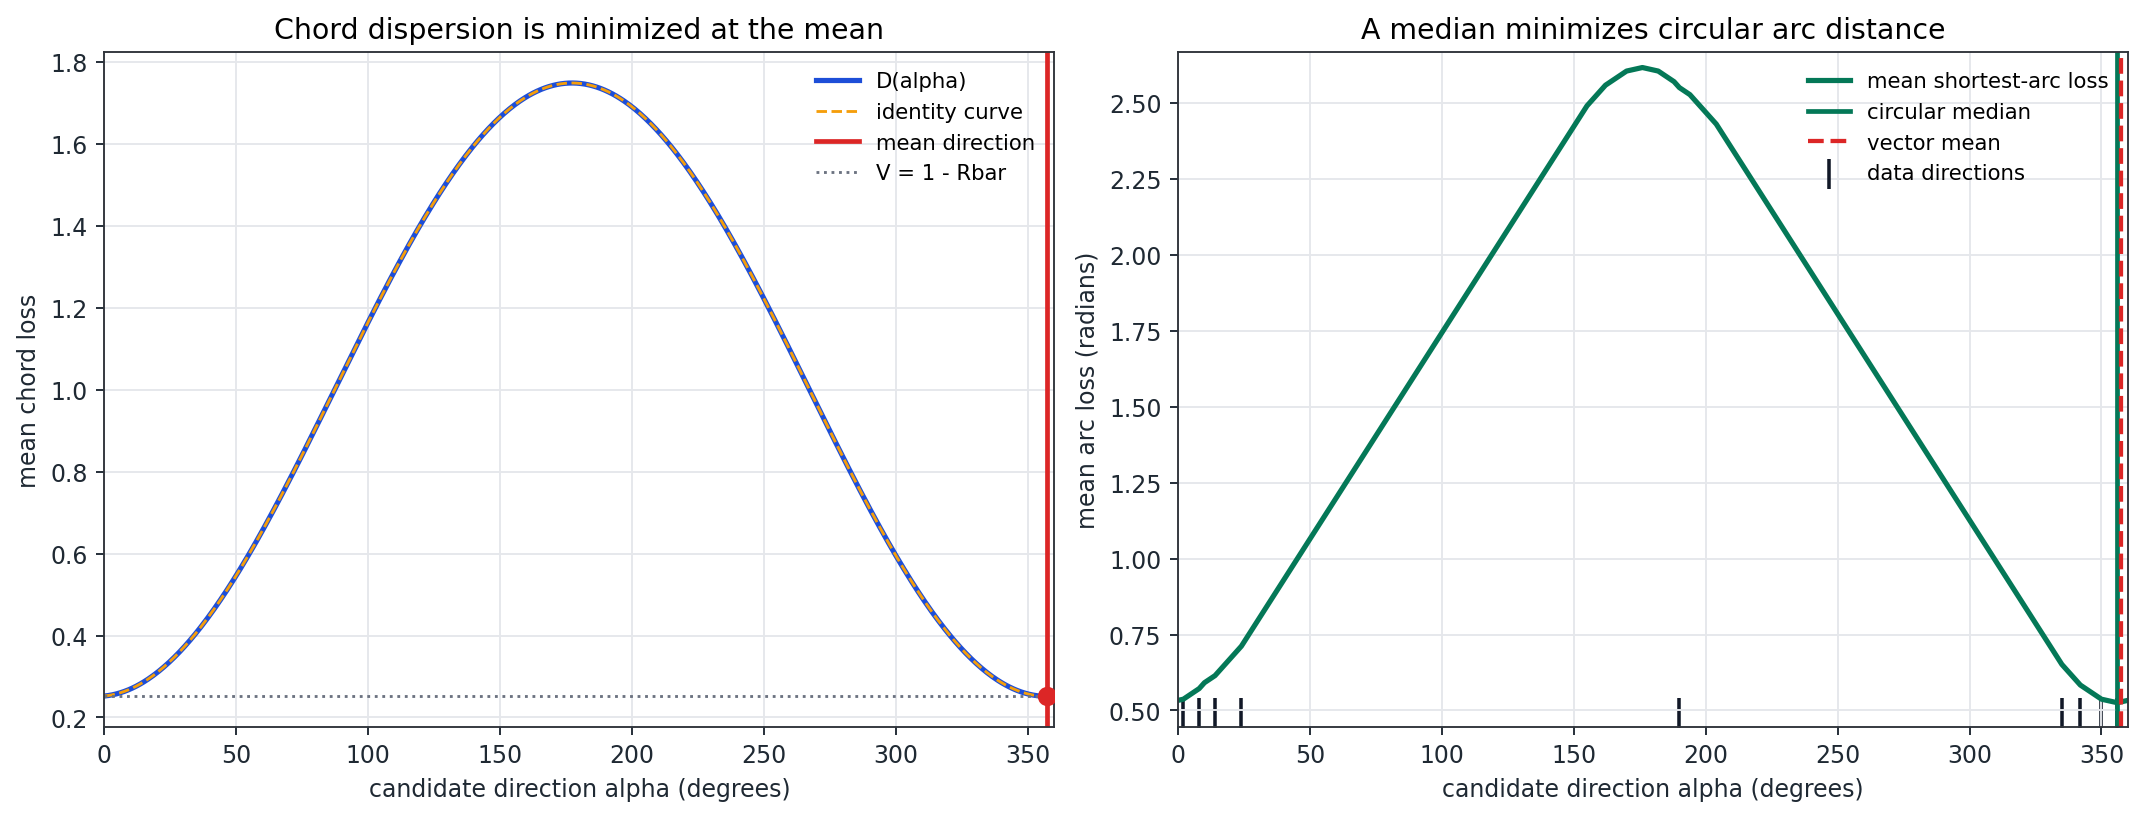

,statistic,value,unit
0,mean direction,357.226489,degrees
1,mean resultant length Rbar,0.748480,unitless
2,circular variance V,0.251520,unitless
3,circular standard deviation,0.761198,radians
4,circular median,356.000000,degrees
5,circular range,194.000000,degrees
6,largest empty arc,166.000000,degrees


In [4]:
robust_degrees = np.array([335, 342, 350, 356, 2, 8, 14, 24, 190], dtype=float)
robust_theta = np.deg2rad(robust_degrees)
robust_summary = resultant(robust_theta)
robust_mu = robust_summary["mean_direction"]
robust_rbar = robust_summary["Rbar"]
robust_variance = 1 - robust_rbar
robust_std = math.sqrt(-2 * math.log(robust_rbar))
median_angle, median_loss = circular_median(robust_theta)
range_length, largest_empty_arc = circular_range(robust_theta)

alpha_grid = np.linspace(0, TAU, 721)
D_values = np.array([chord_dispersion(robust_theta, alpha) for alpha in alpha_grid])
D_identity = robust_variance + robust_rbar * (1 - np.cos(wrap_pi(alpha_grid - robust_mu)))
L1_values = np.array([circular_l1_loss(robust_theta, alpha) for alpha in alpha_grid])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7), constrained_layout=True)
ax = axes[0]
ax.plot(np.rad2deg(alpha_grid), D_values, color="#1d4ed8", lw=2.2, label="D(alpha)")
ax.plot(np.rad2deg(alpha_grid), D_identity, color="#f59e0b", lw=1.2, ls="--", label="identity curve")
ax.axvline(deg(robust_mu), color="#dc2626", lw=2, label="mean direction")
ax.axhline(robust_variance, color="#6b7280", lw=1.2, ls=":", label="V = 1 - Rbar")
ax.scatter([deg(robust_mu)], [chord_dispersion(robust_theta, robust_mu)], color="#dc2626", s=52, zorder=4)
ax.set_xlabel("candidate direction alpha (degrees)")
ax.set_ylabel("mean chord loss")
ax.set_title("Chord dispersion is minimized at the mean")
ax.set_xlim(0, 360)
ax.grid(True, color="#e5e7eb")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.plot(np.rad2deg(alpha_grid), L1_values, color="#047857", lw=2.2, label="mean shortest-arc loss")
ax.axvline(deg(median_angle), color="#047857", lw=2.0, label="circular median")
ax.axvline(deg(robust_mu), color="#dc2626", lw=1.8, ls="--", label="vector mean")
ax.scatter(deg(robust_theta), np.full_like(robust_theta, L1_values.min() - 0.035),
           marker="|", s=160, color="#111827", label="data directions")
ax.set_ylim(L1_values.min() - 0.08, L1_values.max() + 0.05)
ax.set_xlabel("candidate direction alpha (degrees)")
ax.set_ylabel("mean arc loss (radians)")
ax.set_title("A median minimizes circular arc distance")
ax.set_xlim(0, 360)
ax.grid(True, color="#e5e7eb")
ax.legend(frameon=False, fontsize=9)

dispersion_path = save_matplotlib(fig, TOPIC, "figures", "dispersion-median-losses.png", dpi=170)
plt.close(fig)
display_artifact(dispersion_path, width=900)

concentration_table = pd.DataFrame([
    {"statistic": "mean direction", "value": deg(robust_mu), "unit": "degrees"},
    {"statistic": "mean resultant length Rbar", "value": robust_rbar, "unit": "unitless"},
    {"statistic": "circular variance V", "value": robust_variance, "unit": "unitless"},
    {"statistic": "circular standard deviation", "value": robust_std, "unit": "radians"},
    {"statistic": "circular median", "value": deg(median_angle), "unit": "degrees"},
    {"statistic": "circular range", "value": np.rad2deg(range_length), "unit": "degrees"},
    {"statistic": "largest empty arc", "value": np.rad2deg(largest_empty_arc), "unit": "degrees"},
])
concentration_table


The dashed identity curve in the first panel is not fitted to the blue curve; it is computed from `V`, `Rbar`, and the sample mean direction. Matching those curves is a direct check that chord dispersion has been decomposed into within-sample variation plus the cost of moving away from the mean. The second panel shows why the median is a robust summary rather than a duplicate of the mean.


## Trigonometric Moments

The first moment is the resultant. Higher trigonometric moments repeat the circle `p` times before averaging: `m'_p = mean(exp(i p theta))`. This makes p-fold structure visible. Centering by the mean direction gives `m_p = mean(exp(i p (theta - mean)))`, which supports circular skewness and kurtosis diagnostics for concentrated unimodal data.


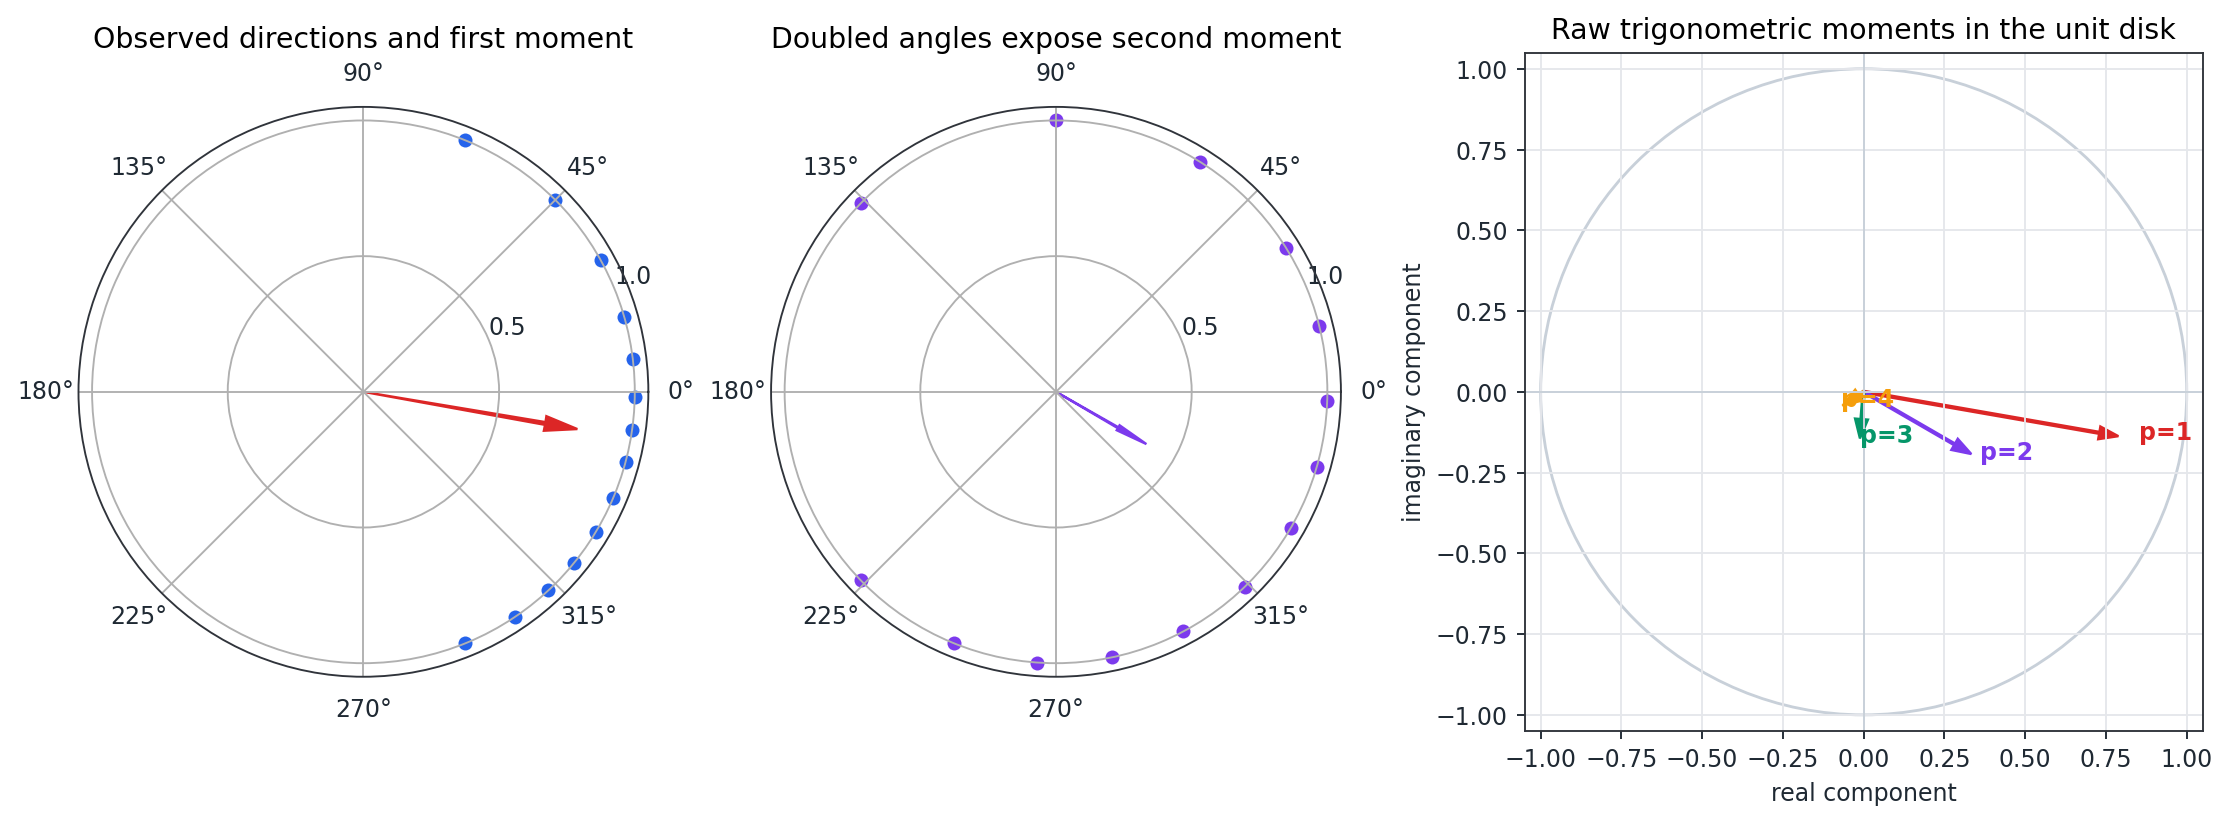

{
  "mean_direction_degrees": 350.12381769188653,
  "R1": 0.8002011613226844,
  "R2": 0.3847861723966623,
  "circular_skewness": -0.7686169569996945,
  "circular_kurtosis": -0.7865378039727209
}


,p,a_p_raw,b_p_raw,R_p,phase_degrees,fold_axis_degrees,u_p_centered,v_p_centered
0,1,0.788343,-0.137250,0.800201,350.123818,350.123818,0.800201,2.379049e-17
1,2,0.333139,-0.192559,0.384786,329.971414,164.985707,0.378614,-6.864350e-02
2,3,-0.011652,-0.144241,0.144711,265.381800,88.460600,0.061181,-1.311418e-01
3,4,-0.065635,-0.042855,0.078387,213.141995,53.285499,-0.023380,-7.481904e-02


In [5]:
moment_degrees = np.array([292, 304, 313, 321, 329, 337, 345, 352, 359, 7, 16, 29, 45, 68], dtype=float)
moment_theta = np.deg2rad(moment_degrees)
moment_summary = resultant(moment_theta)
moment_mu = moment_summary["mean_direction"]

moment_rows = []
for p in range(1, 5):
    raw = trig_moment(moment_theta, p)
    centered = trig_moment(moment_theta, p, center=moment_mu)
    phase = wrap_2pi(np.angle(raw))
    moment_rows.append({
        "p": p,
        "a_p_raw": float(raw.real),
        "b_p_raw": float(raw.imag),
        "R_p": float(abs(raw)),
        "phase_degrees": float(deg(phase)),
        "fold_axis_degrees": float(deg(phase / p)),
        "u_p_centered": float(centered.real),
        "v_p_centered": float(centered.imag),
    })

moment_table = pd.DataFrame(moment_rows)
R1 = float(moment_table.loc[moment_table["p"] == 1, "R_p"].iloc[0])
R2 = float(moment_table.loc[moment_table["p"] == 2, "R_p"].iloc[0])
theta2 = np.angle(trig_moment(moment_theta, 2))
skewness = R2 * np.sin(wrap_pi(theta2 - 2 * moment_mu)) / ((1 - R1) ** 1.5)
kurtosis = (R2 * np.cos(wrap_pi(theta2 - 2 * moment_mu)) - R1 ** 4) / ((1 - R1) ** 2)

moments_csv_path = BOOK_ROOT / "artifacts" / TOPIC / "tables" / "trigonometric-moments.csv"
moments_csv_path.parent.mkdir(parents=True, exist_ok=True)
moment_table.to_csv(moments_csv_path, index=False)

fig = plt.figure(figsize=(13, 4.8), constrained_layout=True)
gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.05, 1.25])
ax0 = fig.add_subplot(gs[0, 0], projection="polar")
ax1 = fig.add_subplot(gs[0, 1], projection="polar")
ax2 = fig.add_subplot(gs[0, 2])

ax0.scatter(moment_theta, np.ones_like(moment_theta), s=44, color="#2563eb", edgecolor="white", linewidth=0.7)
ax0.arrow(moment_mu, 0, 0, R1, color="#dc2626", width=0.015, head_width=0.08, length_includes_head=True)
ax0.set_rticks([0.5, 1.0])
ax0.set_title("Observed directions and first moment")

ax1.scatter(wrap_2pi(2 * moment_theta), np.ones_like(moment_theta), s=44, color="#7c3aed", edgecolor="white", linewidth=0.7)
ax1.arrow(wrap_2pi(theta2), 0, 0, R2, color="#7c3aed", width=0.015, head_width=0.08, length_includes_head=True)
ax1.set_rticks([0.5, 1.0])
ax1.set_title("Doubled angles expose second moment")

circle = plt.Circle((0, 0), 1, color="#c8d0d9", fill=False, lw=1.2)
ax2.add_patch(circle)
colors = ["#dc2626", "#7c3aed", "#059669", "#f59e0b"]
for row, color in zip(moment_rows, colors):
    ax2.arrow(0, 0, row["a_p_raw"], row["b_p_raw"],
              color=color, width=0.006, head_width=0.04, length_includes_head=True)
    ax2.text(row["a_p_raw"] * 1.08, row["b_p_raw"] * 1.08, f"p={row['p']}", color=color, weight="bold")
ax2.axhline(0, color="#c8d0d9", lw=0.8)
ax2.axvline(0, color="#c8d0d9", lw=0.8)
ax2.set_aspect("equal", adjustable="box")
ax2.set_xlim(-1.05, 1.05)
ax2.set_ylim(-1.05, 1.05)
ax2.set_xlabel("real component")
ax2.set_ylabel("imaginary component")
ax2.set_title("Raw trigonometric moments in the unit disk")
ax2.grid(True, color="#e5e7eb")

moments_path = save_matplotlib(fig, TOPIC, "figures", "trigonometric-moments-dashboard.png", dpi=170)
plt.close(fig)
display_artifact(moments_path, width=920)
display_artifact(moments_csv_path)

moment_diagnostics = {
    "mean_direction_degrees": float(deg(moment_mu)),
    "R1": R1,
    "R2": R2,
    "circular_skewness": float(skewness),
    "circular_kurtosis": float(kurtosis),
}
print(json.dumps(moment_diagnostics, indent=2))
moment_table


In the dashboard, the second polar panel is not another display of the same data; it is the data after the map `theta -> 2 theta`. If a sample has axial or two-fold structure, that transformation turns opposing directions into agreement. The unit-disk panel then compares several moment vectors on the same scale.


## Applied Lab: Cutpoints, Grouping, And Corrections

This lab stresses two mistakes that are easy to make in circular summaries.

First, moving the cut point before taking a linear mean can create a different answer from the same directions. Second, replacing grouped observations by bin midpoints shortens resultants on average. For equal bin width `h`, the standard midpoint correction multiplies `R_p` by `a(p h) = (p h / 2) / sin(p h / 2)`. Here we use the first resultant, so the factor is `a(h)`.

The Plotly artifact is meant to be inspected with hover labels. The top panel shows the cutpoint failure curve. The bottom panel compares the exact resultant length from a simulated exact-angle sample with grouped midpoint estimates before and after the correction.


In [6]:
grouping_theta = RNG.vonmises(mu=np.deg2rad(340), kappa=3.0, size=1200)
true_group_summary = resultant(grouping_theta)
true_group_rbar = true_group_summary["Rbar"]

h_degrees = np.array([5, 10, 15, 20, 30, 45, 60, 90], dtype=float)
group_rows = []
for hdeg in h_degrees:
    h = np.deg2rad(hdeg)
    mids, indices, bin_count = grouped_midpoints(grouping_theta, h)
    grouped_rbar = resultant(mids)["Rbar"]
    factor = grouping_correction_factor(h)
    corrected = factor * grouped_rbar
    group_rows.append({
        "bin_width_degrees": hdeg,
        "bin_count": bin_count,
        "true_Rbar": true_group_rbar,
        "grouped_midpoint_Rbar": grouped_rbar,
        "correction_factor_a_h": factor,
        "corrected_Rbar": corrected,
        "absolute_error_grouped": abs(grouped_rbar - true_group_rbar),
        "absolute_error_corrected": abs(corrected - true_group_rbar),
    })

grouping_table = pd.DataFrame(group_rows)
grouping_csv_path = BOOK_ROOT / "artifacts" / TOPIC / "tables" / "grouping-correction.csv"
grouping_csv_path.parent.mkdir(parents=True, exist_ok=True)
grouping_table.to_csv(grouping_csv_path, index=False)

h = sp.symbols("h")
series_expr = sp.series((h / 2) / sp.sin(h / 2), h, 0, 6)

fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=("Linear mean depends on the cut point", "Grouping correction for the mean resultant length"),
    vertical_spacing=0.18,
)
fig.add_trace(
    go.Scatter(
        x=np.rad2deg(cut_grid),
        y=np.rad2deg(linear_curve),
        mode="lines",
        name="linear mean after cut",
        line={"color": "#4b5563", "width": 3},
        hovertemplate="cut=%{x:.0f} deg<br>linear mean=%{y:.1f} deg<extra></extra>",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=[0, 360],
        y=[deg(mu), deg(mu)],
        mode="lines",
        name="circular mean",
        line={"color": "#dc2626", "width": 3},
        hovertemplate="circular mean=%{y:.1f} deg<extra></extra>",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=grouping_table["bin_width_degrees"],
        y=grouping_table["grouped_midpoint_Rbar"],
        mode="lines+markers",
        name="grouped midpoint Rbar",
        line={"color": "#2563eb", "width": 3},
        hovertemplate="h=%{x:.0f} deg<br>grouped Rbar=%{y:.4f}<extra></extra>",
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=grouping_table["bin_width_degrees"],
        y=grouping_table["corrected_Rbar"],
        mode="lines+markers",
        name="a(h) corrected Rbar",
        line={"color": "#059669", "width": 3},
        hovertemplate="h=%{x:.0f} deg<br>corrected Rbar=%{y:.4f}<extra></extra>",
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=[h_degrees.min(), h_degrees.max()],
        y=[true_group_rbar, true_group_rbar],
        mode="lines",
        name="exact-angle Rbar",
        line={"color": "#111827", "width": 2, "dash": "dash"},
        hovertemplate="exact Rbar=%{y:.4f}<extra></extra>",
    ),
    row=2,
    col=1,
)
fig.update_xaxes(title_text="cut point (degrees)", range=[0, 360], row=1, col=1)
fig.update_yaxes(title_text="reported mean (degrees)", range=[0, 360], row=1, col=1)
fig.update_xaxes(title_text="equal bin width h (degrees)", row=2, col=1)
fig.update_yaxes(title_text="mean resultant length", row=2, col=1)
fig.update_layout(
    height=760,
    width=980,
    template="plotly_white",
    legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "xanchor": "left", "x": 0},
    margin={"l": 70, "r": 30, "t": 95, "b": 70},
)

interactive_path = save_plotly_html(fig, TOPIC, "interactive", "cutpoint-grouping-lab.html", include_plotlyjs=True)
legacy_interactive_path = save_plotly_html(fig, TOPIC, "interactive", "exploration.html", include_plotlyjs=True)
display_artifact(interactive_path, width="100%", height=780)
display_artifact(grouping_csv_path)

grouping_diagnostics = {
    "true_Rbar": float(true_group_rbar),
    "series_a_h": str(series_expr),
    "factor_at_45_degrees": float(grouping_correction_factor(np.deg2rad(45))),
    "fine_bins_factor_below_1_03": bool(grouping_correction_factor(np.deg2rad(45)) <= 1.03),
    "correction_improves_error_for_15_to_90_degrees": bool(
        (
            grouping_table.loc[grouping_table["bin_width_degrees"].isin([15, 20, 30, 45, 60, 90]), "absolute_error_corrected"].to_numpy()
            < grouping_table.loc[grouping_table["bin_width_degrees"].isin([15, 20, 30, 45, 60, 90]), "absolute_error_grouped"].to_numpy()
        ).all()
    ),
}
print(json.dumps(grouping_diagnostics, indent=2))
grouping_table


{
  "true_Rbar": 0.7991782065007375,
  "series_a_h": "1 + h**2/24 + 7*h**4/5760 + O(h**6)",
  "factor_at_45_degrees": 1.026172152977031,
  "fine_bins_factor_below_1_03": true,
  "correction_improves_error_for_15_to_90_degrees": true
}


,bin_width_degrees,bin_count,true_Rbar,grouped_midpoint_Rbar,correction_factor_a_h,corrected_Rbar,absolute_error_grouped,absolute_error_corrected
0,5.0,72,0.799178,0.799227,1.000317,0.799481,0.000049,0.000302
1,10.0,36,0.799178,0.797408,1.001270,0.798421,0.001770,0.000757
2,15.0,24,0.799178,0.796845,1.002862,0.799125,0.002334,0.000053
3,20.0,18,0.799178,0.793201,1.005095,0.797243,0.005977,0.001936
4,30.0,12,0.799178,0.788635,1.011515,0.797716,0.010544,0.001462
5,45.0,8,0.799178,0.779296,1.026172,0.799692,0.019882,0.000514
6,60.0,6,0.799178,0.759488,1.047198,0.795334,0.039691,0.003845
7,90.0,4,0.799178,0.713771,1.110721,0.792801,0.085407,0.006378


The correction factor is close to one for fine grouping, which is why it matters least when bins are narrow. Coarse bins are different: midpoint grouping hides within-bin angular spread, so the uncorrected resultant is biased downward in the simulated exact-angle sample. The correction is not a cure for every problem. It adjusts concentration under equal-width grouping; it does not make a cut-dependent linear mean legitimate.


## Invariant Scaffolds

The symbolic and numeric checks below are the compact proof skeleton for the chapter.

- Rotating all angles by `delta` must rotate the mean direction by `delta` and preserve `Rbar`.
- The sine residual about the mean direction must sum to zero when the resultant is nonzero.
- The chord-dispersion identity must hold across the whole grid of candidate directions.
- The circular median should minimize the computed shortest-arc loss.
- The first centered trigonometric moment should be real and equal to `Rbar`.
- Grouping correction should be a small perturbation for bins up to 45 degrees.


In [7]:
delta = np.deg2rad(73)
rotated_summary = resultant(wrap_2pi(cutpoint_theta + delta))
expected_rotated_mu = wrap_2pi(mu + delta)
rotation_error = abs(wrap_pi(rotated_summary["mean_direction"] - expected_rotated_mu))
rbar_rotation_error = abs(rotated_summary["Rbar"] - rbar)

sine_residual = float(np.sum(np.sin(cutpoint_theta - mu)))
D_at_mean = chord_dispersion(robust_theta, robust_mu)
dispersion_identity_max_error = float(np.max(np.abs(D_values - D_identity)))
median_loss_grid_min = float(L1_values.min())
median_loss_error = abs(circular_l1_loss(robust_theta, median_angle) - median_loss_grid_min)
first_centered = trig_moment(moment_theta, 1, center=moment_mu)

numeric_checks = {
    "source_span": SOURCE_SPAN,
    "unit_resultant": resultant_diagnostics,
    "concentration_and_dispersion": {
        "D_at_mean": float(D_at_mean),
        "circular_variance": float(robust_variance),
        "D_at_mean_equals_1_minus_Rbar": bool(np.isclose(D_at_mean, robust_variance, atol=1e-12)),
        "dispersion_identity_max_error": dispersion_identity_max_error,
        "circular_standard_deviation_radians": float(robust_std),
        "median_degrees": float(deg(median_angle)),
        "median_loss_error_against_grid": float(median_loss_error),
    },
    "moments": {
        **moment_diagnostics,
        "first_centered_imag_abs": float(abs(first_centered.imag)),
        "first_centered_real_minus_R1": float(abs(first_centered.real - R1)),
    },
    "grouping": grouping_diagnostics,
    "invariants": {
        "mean_direction_rotation_error_radians": float(rotation_error),
        "Rbar_rotation_error": float(rbar_rotation_error),
        "sine_residual_about_mean_abs": float(abs(sine_residual)),
        "sympy_grouping_factor_series": str(series_expr),
    },
}

assert rotation_error < 1e-12, rotation_error
assert rbar_rotation_error < 1e-12, rbar_rotation_error
assert abs(sine_residual) < 1e-12, sine_residual
assert np.isclose(D_at_mean, robust_variance, atol=1e-12)
assert dispersion_identity_max_error < 1e-12, dispersion_identity_max_error
assert median_loss_error < 0.01, median_loss_error
assert abs(first_centered.imag) < 1e-12, first_centered
assert abs(first_centered.real - R1) < 1e-12, first_centered
assert grouping_diagnostics["fine_bins_factor_below_1_03"]
assert "h**2/24" in str(series_expr)

checks_path = save_json(numeric_checks, TOPIC, "checks", "numeric-checks.json")
numeric_checks


{'source_span': {'printed_pages': '13-24',
  'pdf_pages': '32-42',
  'source_use': 'orientation only; no copied prose, tables, screenshots, page crops, or solutions'},
 'unit_resultant': {'n': 9,
  'mean_direction_degrees': 0.6732760516106343,
  'mean_resultant_length': 0.9880961476245924,
  'linear_mean_cut_at_zero_degrees': 160.66666666666669,
  'linear_mean_cut_at_180_degrees': 0.6666666666666591,
  'cutpoint_swing_degrees': 160.00000000000003},
 'concentration_and_dispersion': {'D_at_mean': 0.25152008270461157,
  'circular_variance': 0.25152008270461157,
  'D_at_mean_equals_1_minus_Rbar': True,
  'dispersion_identity_max_error': 8.881784197001252e-16,
  'circular_standard_deviation_radians': 0.7611976170260709,
  'median_degrees': 356.0,
  'median_loss_error_against_grid': 0.0},
 'moments': {'mean_direction_degrees': 350.12381769188653,
  'R1': 0.8002011613226844,
  'R2': 0.3847861723966623,
  'circular_skewness': -0.7686169569996945,
  'circular_kurtosis': -0.7865378039727209,
  '

## Final Sanity Checks

The final cell checks that every artifact used by the notebook exists, has nonzero size, and is tied to a mathematical check. This is intentionally more than a file-existence audit: the resultants, dispersion identity, moments, and grouping correction all have numeric evidence in `numeric-checks.json`.


In [8]:
artifact_paths = [
    resultant_path,
    dispersion_path,
    moments_path,
    interactive_path,
    legacy_interactive_path,
    moments_csv_path,
    grouping_csv_path,
    checks_path,
]

artifact_records = assert_artifacts(artifact_paths, min_bytes=100)
final_sanity = {
    "notebook": "part-01-circular-statistics/chapter-02-summary-statistics/02-summary-statistics.ipynb",
    "source_span": SOURCE_SPAN,
    "topic_checks": numeric_checks,
    "standalone_contract": "original prose, generated chapter-specific visuals, executable checks",
    "pdf_used_for": "source orientation only",
    "artifacts": artifact_records,
    "core_checks": {
        "no_linear_cutpoint_summary_used_for_mean": True,
        "rotation_equivariance_checked": numeric_checks["invariants"]["mean_direction_rotation_error_radians"] < 1e-12,
        "sine_residual_checked": numeric_checks["invariants"]["sine_residual_about_mean_abs"] < 1e-12,
        "dispersion_identity_checked": numeric_checks["concentration_and_dispersion"]["dispersion_identity_max_error"] < 1e-12,
        "moment_centering_checked": numeric_checks["moments"]["first_centered_imag_abs"] < 1e-12,
        "grouping_series_checked": "h**2/24" in numeric_checks["grouping"]["series_a_h"],
    },
    "libraries_used": {
        "numpy": "unit-vector and complex moment computations",
        "scipy.optimize": "nonsmooth circular median refinement",
        "matplotlib": "durable circular diagrams saved as PNG",
        "plotly": "standalone HTML lab for cutpoint and grouping variation",
        "pandas": "auditable moment and grouping tables",
        "sympy": "series check for the grouping correction factor",
    },
}
assert all(final_sanity["core_checks"].values()), final_sanity["core_checks"]
final_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
assert final_path.exists() and final_path.stat().st_size > 100
final_sanity


{'notebook': 'part-01-circular-statistics/chapter-02-summary-statistics/02-summary-statistics.ipynb',
 'source_span': {'printed_pages': '13-24',
  'pdf_pages': '32-42',
  'source_use': 'orientation only; no copied prose, tables, screenshots, page crops, or solutions'},
 'topic_checks': {'source_span': {'printed_pages': '13-24',
   'pdf_pages': '32-42',
   'source_use': 'orientation only; no copied prose, tables, screenshots, page crops, or solutions'},
  'unit_resultant': {'n': 9,
   'mean_direction_degrees': 0.6732760516106343,
   'mean_resultant_length': 0.9880961476245924,
   'linear_mean_cut_at_zero_degrees': 160.66666666666669,
   'linear_mean_cut_at_180_degrees': 0.6666666666666591,
   'cutpoint_swing_degrees': 160.00000000000003},
  'concentration_and_dispersion': {'D_at_mean': 0.25152008270461157,
   'circular_variance': 0.25152008270461157,
   'D_at_mean_equals_1_minus_Rbar': True,
   'dispersion_identity_max_error': 8.881784197001252e-16,
   'circular_standard_deviation_radia

## Takeaways

- A direction is safest as a unit vector or unit complex number; angle labels are coordinates, not the object being measured.
- The vector resultant gives both location and concentration: its direction is the mean direction and its normalized length is `Rbar`.
- Circular dispersion must wrap. Chord dispersion is minimized at the mean direction, while shortest-arc dispersion leads to a circular median.
- Higher trigonometric moments summarize repeated angular structure and support circular skewness/kurtosis diagnostics.
- Grouping correction adjusts resultant lengths for equal-width bins, but it does not rescue summaries that depend on where the circle was cut.
